# Example Workflow Analysis
## A Jupyter notebook containing exploratory data analysis

In [140]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import math
import os

In [141]:
columnStats = pd.read_csv("column-stats.tsv", delimiter="\t")
columnStats["compression_ratio"] = columnStats['unique_values'] / columnStats['total_values']
print(columnStats.head())

                             workflow      file_name      column_name  \
0  2018-05-31-crime-and-heat-analysis  lambert_1.csv          STATION   
1  2018-05-31-crime-and-heat-analysis  lambert_1.csv             NAME   
2  2018-05-31-crime-and-heat-analysis  lambert_1.csv             DATE   
3  2018-05-31-crime-and-heat-analysis  lambert_1.csv             PRCP   
4  2018-05-31-crime-and-heat-analysis  lambert_1.csv  PRCP_ATTRIBUTES   

   total_values  null_values  unique_values  compression_ratio  
0          3653            0              1           0.000274  
1          3653            0              1           0.000274  
2          3653            0           3653           1.000000  
3          3653            0            183           0.050096  
4          3653            0              8           0.002190  


### Compression ratio
When thinking of a value counts calculation as a way of compression column data, you get the following distribution of compression ratios among columns used in example workflows.

In [142]:
print(columnStats['compression_ratio'].describe())

count    492.000000
mean       0.225522
std        0.393978
min        0.000002
25%        0.000547
50%        0.008333
75%        0.076573
max        1.000000
Name: compression_ratio, dtype: float64


<Axes: >

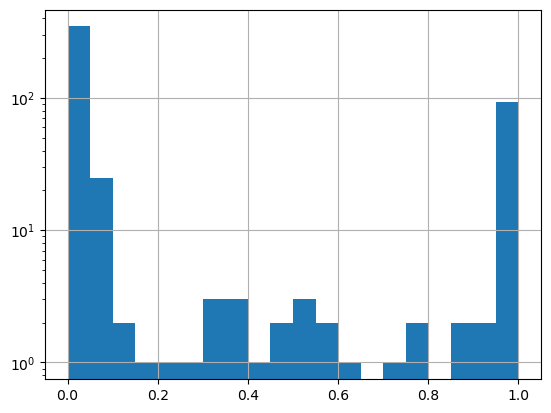

In [143]:
columnStats['compression_ratio'].hist(bins=20, log=True)

<Axes: >

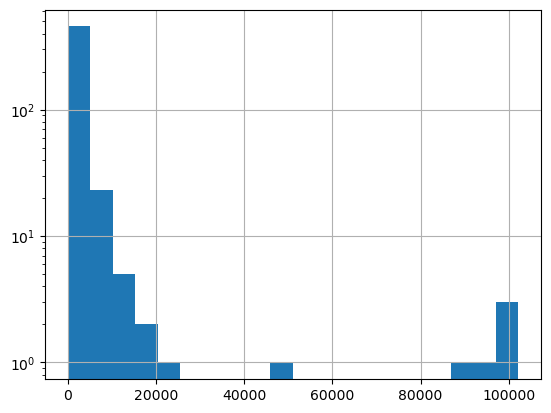

In [144]:
columnStats['unique_values'].hist(bins=20, log=True)

In [145]:
def plot_column_distributions(file_path, limit=1000):
    """
    Plot column value distributions with delta annotations.
    
    Parameters:
    - file_path: Path to the CSV file to analyze
    - limit: Delta value to annotate (default: 1)
    """
    xvar = "unique_percentage"
    xtxt = "index"
    yvar = "cumulative_percentage"
    ytxt = "cumulative_sum"

    # Read and process data
    data_df = pd.read_csv(file_path)
    data_df = data_df.astype(str)
    row_count = len(data_df)

    # Process all columns
    all_distributions = []

    for column in data_df.columns:
        count_distribution = data_df.value_counts(column)
        count_distribution = count_distribution.to_frame(name='count').reset_index()
        count_distribution["column_name"] = column
        count_distribution['index'] = count_distribution.index

        uniq_value_count = len(count_distribution)
        count_distribution["unique_percentage"] = count_distribution.index / uniq_value_count

        count_distribution['cumulative_sum'] = count_distribution['count'].cumsum()
        count_distribution['cumulative_percentage'] = count_distribution["cumulative_sum"] / row_count
        count_distribution['delta'] = count_distribution['cumulative_sum'].rolling(window=2).apply(lambda x: x.iloc[1] - x.iloc[0] if len(x) == 2 else None)
        count_distribution['delta_percentage'] = count_distribution['delta'] / row_count
        all_distributions.append(count_distribution[["column_name", "index", "unique_percentage", "cumulative_sum","cumulative_percentage", "delta"]])

    # Combine all distributions into one DataFrame
    combined_distributions = pd.concat(all_distributions, ignore_index=True)

    # Get unique columns
    columns = combined_distributions['column_name'].unique()
    n_cols = len(columns)

    # Calculate grid dimensions (2 columns)
    n_rows = math.ceil(n_cols / 2)

    # Create subplots in 2-column layout
    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows))

    # Flatten axes array for easier iteration
    axes = axes.flatten()

    # Plot each column in its own subplot
    for i, column_name in enumerate(columns):
        data = combined_distributions[combined_distributions['column_name'] == column_name].copy()
        
        # Create color map based on delta values
        delta_values = data['delta_percentage'].fillna(0)
        norm = plt.Normalize(vmin=delta_values.min(), vmax=delta_values.max())
        colors = cm.viridis(norm(delta_values))
        
        # Plot with scatter to apply colors
        for j in range(len(data) - 1):
            axes[i].plot(data[xvar].iloc[j:j+2], data[yvar].iloc[j:j+2], 
                        color=colors[j], linewidth=2)
        
        # Find first point where index == limit or use last point
        limit_point = data[data['index'] == limit]
        if not limit_point.empty:
            first_point = limit_point.iloc[0]
        elif limit >= len(data):
            # If limit is beyond range, use last point
            first_point = data.iloc[-1]
        else:
            first_point = None
            
        if first_point is not None:
            x_val = first_point[xvar]
            x_txt = first_point[xtxt]
            y_val = first_point[yvar]
            y_txt = first_point[ytxt]
            axes[i].annotate(f'({x_txt}, {y_txt})', 
                            xy=(x_val, y_val), 
                            xytext=(10, 10), 
                            textcoords='offset points',
                            bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
                            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
        
        uniq_count = len(data)
        axes[i].set_title(f'{column_name} (unique values: {uniq_count})')
        axes[i].set_xlabel('Unique values (%)')
        axes[i].set_ylabel("Table rows (%)")
        axes[i].set_ylim(bottom=0)
        axes[i].grid(True, alpha=0.3)
        
        # Add colorbar
        sm = cm.ScalarMappable(cmap=cm.viridis, norm=norm)
        sm.set_array([])
        plt.colorbar(sm, ax=axes[i], label='Row delta (%)')

    # Hide any unused subplots
    for i in range(n_cols, len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.suptitle(f'{file_path} (Limit={limit})', fontsize=16, y=1.001)
    plt.show()

#### Column compression analysis of `2018-05-31-crime-and-heat-analysis`

KeyError: 'delta_percentage'

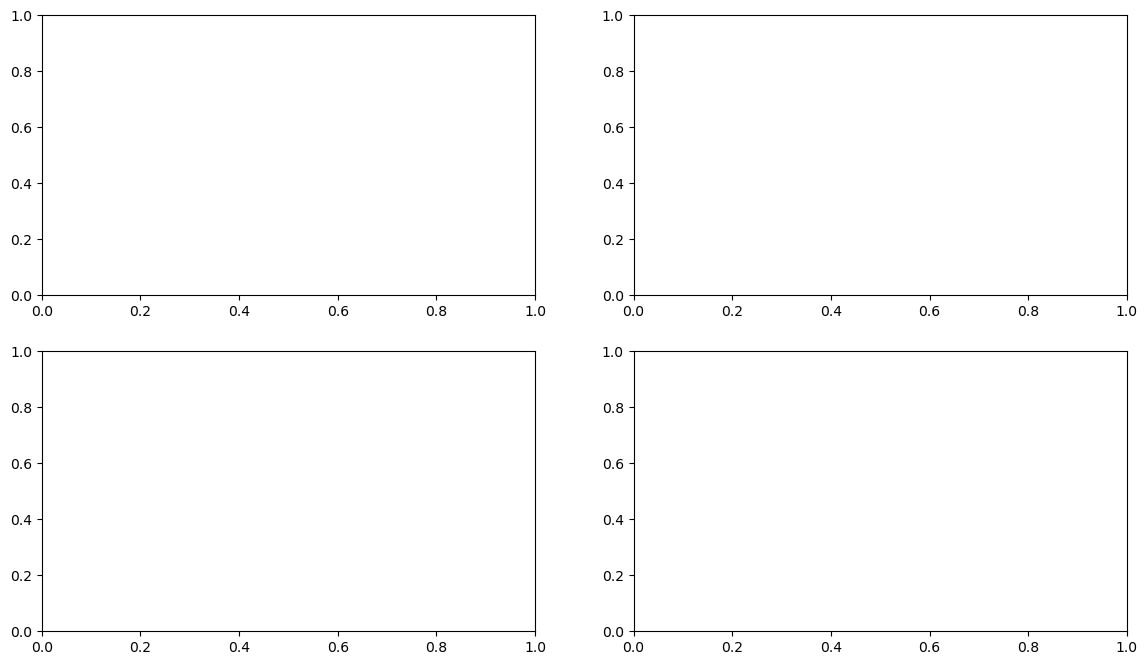

In [146]:
for fileName in ["violent_crimes.csv", "lambert_1.csv", "lambert_2.csv"]:
    plot_column_distributions(f"2018-05-31-crime-and-heat-analysis/{fileName}")

#### 2019-04-democractic-candidate-codonors

In [147]:
# import os

# csv_files = []
# for root, dirs, files in os.walk('2019-04-democratic-candidate-codonors/inputs'):
#     for file in files:
#         if file.lower().endswith('.csv'):
#             csv_files.append(os.path.join(root, file))

# for csv_file in csv_files:
#     plot_column_distributions(csv_file)

#### `babyname_politics`

In [149]:
# csv_files = []
# for root, dirs, files in os.walk('nyc-trips/'):
#     for file in files:
#         if file.lower().endswith('.csv'):
#             csv_files.append(os.path.join(root, file))

# for csv_file in csv_files:
#     plot_column_distributions(csv_file)

#### `school-star-ratings-2018`

In [148]:
# csv_files = []
# for root, dirs, files in os.walk('school-star-ratings-2018/input'):
#     for file in files:
#         if file.lower().endswith('.csv'):
#             csv_files.append(os.path.join(root, file))

# for csv_file in csv_files:
#     plot_column_distributions(csv_file)

In [ ]:
# csv_files = []
# for root, dirs, files in os.walk('babyname_politics/data/states'):
#     for file in files:
#         if file.lower().endswith('.csv'):
#             csv_files.append(os.path.join(root, file))

# for csv_file in csv_files:
#     plot_column_distributions(csv_file)